# 11강 Kernel Methods 1
**참고 교재: Bishop (2006) Chapter 7**

11강에서는 커널 기법과 관련하여 다음의 내용들을 살펴본다.  
- Support Vector Machine(SVM) 이론
- Sparse Kernel Machines에 대한 개념 정리
- **결정 함수**, **최적화 문제** 등을 포함하여 SVM의 기초적인 수학적 배경

## 1. Sparse Kernel Machines

### 1.1 결정 함수(Decision Function)

- **트레이닝 데이터**  
  $$
  D = \{(x_n, t_n)\}_{n=1}^N
  $$
  여기서 $ x_n \in \mathbb{R}^d $는 입력 벡터, $ t_n \in \{-1, +1\}$의 레이블(target)이다.  
  Sparse Kernel Machines에서는 $N$개 데이터 모두를 사용하기보다는 **희소(sparse)** 형태의 해를 찾는 것이 중요하다.

- **커널 머신**(Kernel Machine)의 결정 함수는 일반적으로 다음과 같은 형태로 표현된다.

  $$
  y(x) \;=\; \sum_{n=1}^{N} c_n \, k\bigl(x_n, x\bigr) + b
  $$

  여기서 
  - $c_n$는 학습 과정에서 결정되는 계수(coefficient)로 이진분류의 경우에는 뒤에서 설명할 $\alpha_n t_n$값과 같음
  - $k(\cdot, \cdot)$는 **커널 함수(kernel function)**
  - $b$는 **바이어스(bias)** 
  - $\{ x_n \}_{n=1}^N$는 트레이닝 데이터 세트의 입력 벡터
  - $x \in \mathbb{R}^d $는 테스트 입력 벡터


- 실제 예측 시에 위 식에서 $c_n$이 대부분 0이 되도록 유도하면(**희소성**), 예측 시에 계산해야 하는 $c_n k(x_n, x)$ 항의 개수가 줄어들어 편리하다.  

## 2. Maximum Margin Classifiers (Support Vector Classification)

### 2.1 Linear Separability 가정 (Hard Margin SVM)

먼저, 데이터가 선형으로 완전히 분리되는 경우, 즉, linear separability를 만족하는 경우를 고려해보자.

- **트레이닝 데이터**  
  $$
  D = \{(x_n, t_n)\}_{n=1}^N,\quad t_n \in \{+1, -1\}.
  $$

- **결정 함수(Decision Function)**  
  $$
  y(x) \;=\; \mathbf{w}^T\,\boldsymbol{\phi}(x) \;+\; b
  $$
  - $\boldsymbol{\phi}(x)$는 입력 $x$를 어떤(고차원) 특징 공간(feature space)으로 매핑하는 함수, 즉, 특징 함수(feature map)  
  - $\mathbf{w}$와 $b$는 분류 경계를 정의하는 파라미터

- **선형으로 구분 가능**(linearly separable)이라 가정하면, 다음을 만족하는 $\mathbf{w}$와 $b$가 존재한다.
  $$
  \begin{aligned}
    &\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \;>\; 0 \quad \text{if } t_n = +1,\\
    &\mathbf{w}^T \boldsymbol{\phi}(x_m) + b \;<\; 0 \quad \text{if } t_m = -1.
  \end{aligned}
  $$

### 2.2 Separation Margin $\rho$의 정의

- 분류 초평면(하이퍼플레인, hyperplane)과 데이터 샘플 간의 최소 거리 $\rho$를 **separation margin**이라 한다.  
- 다음 그림에서 초록색 선은 분리 초평면, 검은색 점선들은 데이터와 초평면 사이의 separation margin을 나타낸다.

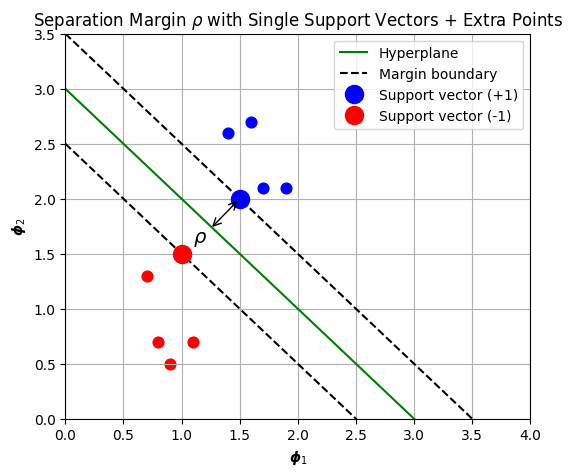

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a simple line (hyperplane): y = slope*x + intercept
slope = -1
intercept = 3.0

def hyperplane(x):
    return slope * x + intercept

# 2. Prepare x-range and corresponding y-values
x_vals = np.linspace(0, 4, 100)
y_vals = hyperplane(x_vals)

# 3. We'll offset the line up/down to visualize the margin
offset = 0.5
y_vals_plus = y_vals + offset
y_vals_minus = y_vals - offset

# 4. Pick exactly one support vector for each class
#    so we can illustrate that they define the margin
plus_sv = np.array([1.5, hyperplane(1.5) + offset])  # +1 class support vector
minus_sv = np.array([1.0, hyperplane(1.0) - offset]) # -1 class support vector

# 5. Create some non-support data points for each class
#    (They are well within their side of the margin.)
# Class +1: points clearly above the hyperplane
plus_data = np.array([
    [1.4, hyperplane(1.4) + 1.0], 
    [1.7, hyperplane(1.7) + 0.8],
    [1.6, hyperplane(1.6) + 1.3],
    [1.9, hyperplane(1.9) + 1.0]
])

# Class -1: points clearly below the hyperplane
minus_data = np.array([
    [0.7, hyperplane(0.7) - 1.0], 
    [0.8, hyperplane(0.8) - 1.5],
    [0.9, hyperplane(0.9) - 1.6],
    [1.1, hyperplane(1.1) - 1.2]
])

# 6. Plot everything
plt.figure(figsize=(6,5))

# Hyperplane
plt.plot(x_vals, y_vals, 'g-', label='Hyperplane')

# Margin boundaries
plt.plot(x_vals, y_vals_plus, 'k--', label='Margin boundary')
plt.plot(x_vals, y_vals_minus, 'k--')

# Support vectors
plt.plot(plus_sv[0], plus_sv[1], marker='o', color='blue', ms=13,
         linestyle='none', label='Support vector (+1)')
plt.plot(minus_sv[0], minus_sv[1], marker='o', color='red', ms=13,
         linestyle='none', label='Support vector (-1)')

# Non-support data points (Class +1)
plt.scatter(plus_data[:,0], plus_data[:,1], c='blue', marker='o', s=60)
# Non-support data points (Class -1)
plt.scatter(minus_data[:,0], minus_data[:,1], c='red', marker='o', s=60)

# 7. Annotate the margin (rho) with an arrow from hyperplane to the +1 support vector
point_on_line = np.array([1.25, 1.75]) -0.15
plt.annotate(
    r'$\rho$', 
    xy=plus_sv,
    xytext=point_on_line,
    arrowprops=dict(arrowstyle='<->'),
    fontsize=14
)

# 8. Cosmetics
plt.title(r"Separation Margin $\rho$ with Single Support Vectors + Extra Points")
plt.xlabel(r"$\boldsymbol{\phi}_1$")
plt.ylabel(r"$\boldsymbol{\phi}_2$")
plt.xlim([0, 4])
plt.ylim([0, 3.5])
plt.grid(True)
plt.legend(loc='upper right')
plt.show()


### 2.3 최대 마진 분류 전략

- **캐노니컬 표현**(canonical representation)은 서포트 벡터에서 결정함수의 출력이 +1 혹은 -1값을 갖도록 스케일링한 표현인데, 이 경우에는 모든 $n$에 대해
  $$
  t_n \times (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b ) \;\ge\; 1
  $$
  이 성립한다.


- 이때, 데이터 중 경계에 있는 항(Support Vectors)에 대해 $ t_n \times (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b) = 1 $이 된다.

- 이 캐노니컬 표현 하에서 separation margin $\rho$는
  $$
  \rho \;=\; \frac{1}{\|\mathbf{w}\|}
  $$
  로 주어진다 (점과 초평면 사이의 거리 공식 참고).
- 머신러닝 모델의 관점에서 이 separation margin을 늘리는 것은 다음과 같은 의미를 갖는다고 볼 수 있다: 
  - 더 나은 일반화(generalization) 성능을 제공할 수 있도록 만든다.
  - 이상치(outliar)에 대해 강건성(robustness)을 지니도록 해준다.


  

## 3. Mathematical Formulation

최대 마진을 찾는 문제는 결국 다음과 같은 최적화 문제로 표현된다:
  $$
  \begin{aligned}
    & \max_{\mathbf{w}, b} \quad \rho \;=\; \frac{1}{\|\mathbf{w}\|} \\
    & \text{subject to } \quad t_n \times (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b ) \;\ge\; 1 \quad \text{for all }\; n=1,\dots,N.
  \end{aligned}
  $$
  이것은 제약이 있는 최적화 문제(Constrained Optimization Problem)로서, Lagrangian(라그랑지안)을 도입하여 해결할 수 있다.
  통상적으로 이를 보다 표준화된 형태인 **Quadratic Program**(QP) 최적화 문제로 만들기 위해 목적함수를
  $$\min_{\mathbf{w}, b} \tfrac{1}{2}\|\mathbf{w}\|^2$$로 변환하여 푼다.

### 3.1 Lagrangian

앞에서 언급한 바와 같이 Support Vector Classifier(SVC)의 최적화 문제를 다음 Quadratic Program 형태로 정리할 수 있다:

$$
\begin{aligned}
& \min_{\mathbf{w}, b} \quad \frac{1}{2}\|\mathbf{w}\|^2 \\
& \text{subject to } \quad 1 - t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \bigr) \le 0, \quad \text{for all }\; n=1,\dots,N.
\end{aligned}
$$

- $\mathbf{w} \in \mathbb{R}^d$와 $b \in \mathbb{R}$는 결정 초평면의 파라미터
- $\boldsymbol{\phi}(\cdot)$는 특징 공간(feature space)으로의 매핑하는 특징 함수(feature map)
- $t_n \in \{+1, -1\}$는 데이터 타겟(레이블)

위와 같은 **제약 조건**(Constraints)이 포함된 **최소화 문제**를 푸는 핵심기술이 바로 **Lagrangian**(라그랑지안)과 **KKT 조건**(뒤에서 설명)이다.


### 3.2 라그랑지안(Lagrangian) 정의

위의 최적화 문제에 대한 **라그랑지안**은 다음과 같이 정의한다.

$$
\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) 
= \frac{1}{2}\|\mathbf{w}\|^2 + \sum_{n=1}^N \alpha_n \Bigl[1 - t_n (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b)\Bigr],
$$


여기서,

- $\boldsymbol{\alpha} = [\alpha_1, \alpha_2, \cdots, \alpha_N ]^T$

- 여기서, $\alpha_n$은 $n$번째 **부등식 제약 조건**  $ 1 - t_n (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b ) \le 0$에 대응하는 라그랑주 승수로, $\alpha_n \ge 0$를 만족해야 한다.


### 3.3 KKT (Karush-Kuhn-Tucker) 조건 

**KKT 조건**은 제약이 있는 최적화 문제(Constrained Optimization Problem)에서 해 $\mathbf{w}^*, b^*, \boldsymbol{\alpha}^*$가 만족해야 하는 필수 조건들을 의미한다. 다음 네 가지 조건을 모두 만족하면 해가 된다.

1. **Stationarity 조건**  
   $$
   \frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0, 
   \quad
   \frac{\partial \mathcal{L}}{\partial b} = 0.
   $$
   즉, $\mathbf{w}$와 $b$에 대해 라그랑지안을 미분했을 때 0이 되어야 한다.

2. **Primal feasibility (프라이멀 타당성)**

   $$
1 - t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \bigr) \le 0, \quad n=1,\dots,N.
   $$

4. **Dual feasibility (듀얼 타당성)**  
   $$
   \alpha_n \ge 0, \quad n=1,\dots,N.
   $$

5. **Complementary slackness (상호 보완성)**  
   $$
   \alpha_n \bigl[1 - t_n(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b)\bigr] = 0, \quad n=1,\dots,N.
   $$
   - 만약 $\alpha_n > 0$라면, 해당 데이터($x_n$)는 결정 초평면에서 **마진 경계** 위에 위치하여 $t_n(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b) - 1 = 0$을 만족하는 서포트 벡터가 됨.  
   - 반대로 $t_n(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b) - 1 > 0$라면, $\alpha_n = 0$. 

이 **KKT 조건**을 통해, 서포트 벡터(Support Vector)가 아닌 데이터에 대응하는 $\alpha_n$은 모두 $0$이 되므로, 실제로 sparse한 solution이 얻어지게 된다.

## 4. 파이썬 예시를 통해 살펴보는 Quadratic Program (QP) 및 KKT 조건

먼저 **SVM**이 아닌, **일반적인 제약 최적화** 문제의 해결 방법에 친숙해져보자.

쉬운 QP 문제를 정의해서,

1. 직관적인 해를 구하고,

2. 파이썬 `scipy`를 이용해 **최적해**를 구하고,

3. KKT 조건(라그랑주 승수, 제약조건)을 이용해 최적해를 구해보자.

다음 최적화 문제를 보자:

$$
\begin{aligned}
\min_{x_1, x_2} \quad & f(x_1, x_2) = x_1^2 + x_2^2 \\
\text{subject to} \quad & x_1 \ge 1, \\
                        & x_2 \ge 2.
\end{aligned}
$$

- 목적함수(2차식): $f(x) = x_1^2 + x_2^2$는 $\mathbf{x}$부터 원점까지의 거리를 제곱한 값이다.
- 제약조건(1차 부등식): $x_1 \ge 1$, $x_2 \ge 2$를 만족해야 한다.

### 4.1 직관적인 해
직관적으로, $[1,2]$가 목적함수를 최소화시키면서(원점으로부터 가장 가까움) 제약 조건을 만족하는 해가 된다.

### 4.2 파이썬으로 최적해 구하기
$\mathbf{x} = [x_1 , x_2 ] =[1, 2]$라는 직관적인 최적해를 scipy.optimize에 있는 minimize 함수를 이용하여 직접 구해보자.

In [1]:
import numpy as np
from scipy.optimize import minimize

def objective(x):
    """
    목적함수: f(x) = x1^2 + x2^2
    """
    return x[0]**2 + x[1]**2

# 제약: x1 >= 1, x2 >= 2 
# -> scipy에서는 'ineq' 타입으로 fun(x) >= 0 형태가 되어야 하므로
#    x1 - 1 >= 0, x2 - 2 >= 0 로 작성
constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 1},
    {'type': 'ineq', 'fun': lambda x: x[1] - 2},
]

# 초기값 설정
x0 = np.array([0.0, 0.0])

# 최적화 수행
solution = minimize(
    fun=objective,      # 목적함수
    x0=x0,              # 초기값
    constraints=constraints # 제약조건
)

# 결과 출력
print("최적해 (x1, x2):", solution.x)
print("최적값 f(x1, x2):", solution.fun)
print("성공 여부:", solution.success)


최적해 (x1, x2): [1. 2.]
최적값 f(x1, x2): 4.999999999999997
성공 여부: True


**파이썬 결과 해석:**

- `solution.x`는 제약을 만족하는 최적 해 $\mathbf{x}^*$이고, 보통 `[1. 2.]` 근처로 수렴한다.
- `solution.fun`은 최적 목적함수 값이며, 이 예제에서는 $1^2 + 2^2 = 5.0$이 된다.
- `solution.success == True`라면 알고리즘이 정상적으로 종료되었음을 뜻한다.

### 4.3 KKT 조건을 통한 Quadratic Program 풀이

위의 제약 최적화 문제를 **KKT(Karush-Kuhn-Tucker)** 조건을 이용해 직접 풀어보자.

$$
\begin{aligned}
&\min_{x_1, x_2} \quad f(x_1, x_2) = x_1^2 + x_2^2 \\
&\text{subject to} \quad x_1 \ge 1,\quad x_2 \ge 2.
\end{aligned}
$$

#### 4.3.1 제약조건 형태 바꾸기

일반적으로 부등식 제약조건을 $g_i(\mathbf{x}) \le 0$ 형태로 고쳐쓰면 편리하다.   
문제에서 $x_1 \ge 1, x_2 \ge 2$이므로 다음과 같이 변형할 수 있다.

$$
\begin{aligned}
g_1(x_1, x_2) &= 1 - x_1 \le 0, \\
g_2(x_1, x_2) &= 2 - x_2 \le 0.
\end{aligned}
$$

즉, 
$$
x_1 \ge 1 \;\; \Longleftrightarrow \;\; 1 - x_1 \le 0, 
\quad
x_2 \ge 2 \;\; \Longleftrightarrow \;\; 2 - x_2 \le 0.
$$

#### 4.3.2 라그랑지안(Lagrangian) 정의

해당 문제의 **라그랑지안**은 다음과 같다.

$$
\mathcal{L}(x_1, x_2, \alpha_1, \alpha_2) 
= x_1^2 + x_2^2 + \alpha_1 (\,1 - x_1\,) + \alpha_2 (\,2 - x_2\,),
$$

여기서 $\alpha_1, \alpha_2 \ge 0$는 (부등식) 제약 조건에 대한 **라그랑주 승수**이다.

#### 4.3.3 KKT 조건 확인하기

KKT 조건의 각 항목을 문제에 대입해보면,

1. **Stationarity 조건**  
   $$
   \frac{\partial \mathcal{L}}{\partial x_1} 
   = 2 x_1 - \alpha_1 = 0, 
   \quad
   \frac{\partial \mathcal{L}}{\partial x_2} 
   = 2 x_2 - \alpha_2 = 0.
   $$
2. **Primal feasibility (프라이멀 제약 충족)**  
   $$
   g_1(x_1, x_2) = 1 - x_1 \le 0,
   \quad
   g_2(x_1, x_2) = 2 - x_2 \le 0.
   $$
3. **Dual feasibility (듀얼문제의 제약 충족)**  
   $$
   \alpha_1 \ge 0, 
   \quad
   \alpha_2 \ge 0.
   $$
4. **Complementary slackness (상보성 조건)**  
   $$
   \alpha_1 \,(1 - x_1) = 0, 
   \quad
   \alpha_2 \,(2 - x_2) = 0.
   $$
   

#### 4.3.4 해 구하기

위 조건들을 만족하는 $(x_1, x_2)$와 $(\alpha_1, \alpha_2)$를 찾아보자.

##### **4.3.4.1 제약이 활성화(active) 되지 않는 경우**

만약, $x_1 > 1$, $x_2 > 2$이라면, KKT 조건 중 4번 complementary slackness에 의해서 $\alpha_1$, $\alpha_2$는 자동적으로 0이 된다.

그렇게 되면, 

   $$
   \frac{\partial \mathcal{L}}{\partial x_1} = 2 x_1 ,  \quad   \frac{\partial \mathcal{L}}{\partial x_2} = 2 x_2 .
   $$


여기서,  $x_1 > 1$, $x_2 > 2$이므로 각각의 미분값이 양수이다. 즉, $f(x_1 , x_2 )$의 최소값을 구하려면 $x_1 , x_2 $가 최대한 작아져야 하는 상황이다. $x_1 , x_2 $가 작아지다보면, 각각의 제약조건 경계까지 도달하게 된다.


##### **4.3.4.2 제약이 활성화(active) 된 경우**
- 만약 $x_1 = 1$이 실제 해에서 활성화(경계 위)된다면,  
  $$
  1 - x_1 = 0 \quad \Longrightarrow \quad g_1(\mathbf{x}) = 0,
  $$
  이때, $\alpha_1$는 (0이 아닐 수 있는) 어떤 양의 값이 가능함.
- 마찬가지로 $x_2 = 2$ 또한 활성화된다고 하면,  
  $$
  2 - x_2 = 0 \quad \Longrightarrow \quad g_2(\mathbf{x}) = 0,
  $$
  $\alpha_2$ 역시 (0이 아닐 수 있는) 어떤 양의 값이 가능함.

이 경우 **complementary slackness**, 즉
$$
\alpha_1 (1 - x_1) = \alpha_1 \cdot 0 = 0, 
\quad
\alpha_2 (2 - x_2) = \alpha_2 \cdot 0 = 0,
$$
가 자동으로 성립한다.

##### **4.3.4.3 Stationarity 해석**
활성 가정대로 $x_1 = 1$, $x_2 = 2$라면,
$$
\begin{aligned}
&2 x_1 - \alpha_1 = 0 \quad \longrightarrow \quad 2(1) - \alpha_1 = 0 \quad \longrightarrow \quad \alpha_1 = 2, \\
&2 x_2 - \alpha_2 = 0 \quad \longrightarrow \quad 2(2) - \alpha_2 = 0 \quad \longrightarrow \quad \alpha_2 = 4.
\end{aligned}
$$

$\alpha_1 = 2, \alpha_2 = 4$는 **Dual feasibility**($\alpha_i \ge 0$)에 부합한다.

##### **4.3.4.4 전체 조건 검증**

$x_1 = 1$, $x_2 = 2$ 일 때,

- **Stationarity**: 위에서 구한 값으로 $\nabla_{\mathbf{x}} \mathcal{L} = 0$  성립

- **Primal feasibility**: $x_1 \ge 1$, $x_2 \ge 2$  성립

- **Dual feasibility**: $\alpha_1 = 2 \ge 0, \alpha_2 = 4 \ge 0$  성립

- **Complementary slackness**: $\alpha_1(1 - 1) = 2 \cdot 0 = 0$, $\alpha_2(2 - 2) = 4 \cdot 0 = 0$  성립

##### **4.3.4.5 결론 요약**

결과적으로, **KKT 조건**을 만족하는 해는

$$
x_1^* = 1,\quad x_2^* = 2,\quad \alpha_1^* = 2,\quad \alpha_2^* = 4 .
$$
여기서, 두 제약 모두 활성(= 경계 위)이고, **최적값**은
$$
f(x_1^*, x_2^*) = (1)^2 + (2)^2 = 1 + 4 = 5.
$$

## 5. 듀얼(dual) 문제

다시 원래의 (Hard Margin) SVM 문제로 돌아와보자.

$$
\begin{aligned}
& \min_{\mathbf{w}, b} \quad \frac{1}{2}\|\mathbf{w}\|^2 \\
& \text{subject to } \quad 1 - t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \bigr) \le 0, \quad \text{for all }\; n=1,\dots,N.
\end{aligned}
$$
위 식을 최소화하는(즉, 마진 $\rho$를 최대화하는) $\mathbf{w}, b,$를 구하는 것이 **프라이멀 문제**(primal problem)이고, 이 때 $\mathbf{w}, b,$는 **프라이멀 변수**이다.


제약조건이 부등식으로 존재하기 때문에 이를 반영하여 다음과 같이 **제약조건** $\le$ 0 형태 및, **라그랑주 승수** $\ge$ 0 형태인 라그랑지안을 정의하였다.

$$
\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) 
= \frac{1}{2}\|\mathbf{w}\|^2 + \sum_{n=1}^N \alpha_n \Bigl[1 - t_n (\mathbf{w}^T \boldsymbol{\phi}(x_n) + b)\Bigr].
$$

위 라그랑지안을 $\mathbf{w}, b$에 대해 최소화하고, $\boldsymbol{\alpha}$에 대해 정리해보자 (Stationarity 조건을 유도).

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0
\;\Longrightarrow\;
\mathbf{w} = \sum_{n=1}^N \alpha_n t_n \boldsymbol{\phi}(x_n).
$$
$$
\frac{\partial \mathcal{L}}{\partial b} = 0
\;\Longrightarrow\;
\sum_{n=1}^N \alpha_n t_n = 0.
$$

즉, 다음과 같이 요약된다:
- $\mathbf{w}$는 학습 데이터 feature들의 선형 결합$\left(\sum \alpha_n t_n \boldsymbol{\phi}(x_n)\right)$  
- $\sum_{n=1}^N \alpha_n t_n = 0$ 라는 추가 조건

그리하여, 프라이멀 문제는 다음과 같이 $W(\boldsymbol{\alpha})$의 최대값을 구하는 **듀얼 문제**(dual problem)의 형태가 된다:

$$
\begin{aligned}
 \max_{\boldsymbol{\alpha}}& \quad W(\boldsymbol{\alpha}) 
= \sum_{n=1}^N \alpha_n - \frac{1}{2} \sum_{n=1}^N \sum_{m=1}^N \alpha_n \alpha_m \,t_n t_m \,\boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m), \\
 \text{subject to} &\quad \sum_{n=1}^N \alpha_n t_n = 0, \quad \alpha_n \ge 0 \; (n=1,\dots,N).
\end{aligned}
$$

여기서
- $\boldsymbol{\alpha} = [\alpha_1, \alpha_2, \cdots, \alpha_N ]^T$는 **듀얼 변수**
- $W(\boldsymbol{\alpha}) = \mathcal{L}(\mathbf{w}^*, b^*, \boldsymbol{\alpha}) $
- $\boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m)$는 **커널 함수** $k(x_n, x_m)$로 대체 가능.  즉, 다음과 같은 **Kernel Trick**(커널 트릭)을 이용하여 편리하게 계산할 수 있다:  
$k(x_n, x_m) = \;<\boldsymbol{\phi}(x_n), \boldsymbol{\phi}(x_m)>$을 통해 고차원 feature map $\boldsymbol{\phi}(x)$를 직접 계산하지 않고도, 위의 최적화 문제에 등장하는 $\boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m)$항을 $k(x_n, x_m)$로 치환하여 계산 가능

**정리하면, SVM 맥락하에서** 선형 제약을 가진 QP 문제(프라이멀 문제)는 다음의 Strong Duality를 만족한다 (자세한 수학적 증명은 생략).

$$\min_{\mathbf{w},b} \frac{1}{2}\|\mathbf{w}\|^2  = \max_{\boldsymbol{\alpha}} W(\boldsymbol{\alpha})$$

그리하여, 듀얼 문제를 풀면 (즉, $W(\boldsymbol{\alpha})$의 최대값을 제약조건 하에서 구하면), 그 해는 프라이멀 문제의 해와 일치한다. 즉, $\frac{1}{2}\|\mathbf{w}\|^2$의 최소값과 일치한다. (마치, 말 안장을 측면에서 바라볼 때에는 최저점을 구하는 문제가, 후면에서 바라볼 때에는 최고점을 구하는 문제와 같고, 각 상황에서의 최적값이 서로 같다는 것과 비슷함으로 비유할 수 있다)

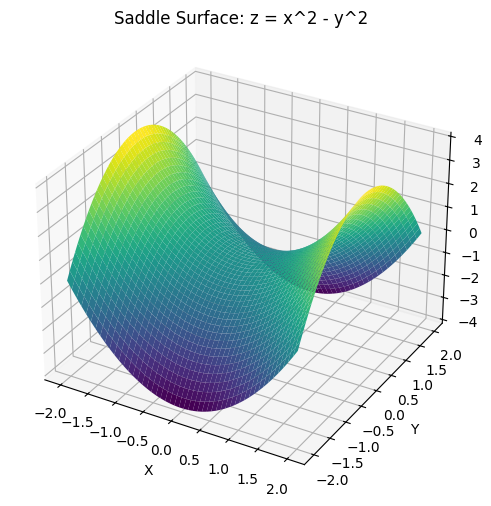

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

# 예: z = x^2 - y^2 형태의 표면 (말 안장)
Z = X**2 - Y**2

# 2. 그래프 그리기
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3. 말 안장 모양의 표면(surface) 플롯
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_title('Saddle Surface: z = x^2 - y^2')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


### 5.1 Mercer's Theorem 

커널 트릭 사용의 정당성을 뒷받침하는 **Mercer’s theorem**에 대해 엄밀한 수학적 증명 없이 개략적으로 살펴보자.  

이 정리를 통해, 어떤 함수가 **내적**(inner product)을 대신하여 사용 가능한 **커널**(kernel)로 작동할 수 있는지 확인할 수 있다.

**Mercer 정리(Rough Statement)**

> “어떤 대칭 함수 $ k(x,y) $가 (특정 공간에서) 정의되고,  
> 모든 $f\in L_2$에 대해$\iint k(x,y)\,f(x)\,f(y)\,dx\,dy \;\ge\; 0$가 성립하면,  
> 적절한(잠재적으로 고차원 혹은 무한 차원인 입력 공간 위에 정의된) 매핑 $\boldsymbol{\phi}$가 존재하여  
> $k(x,y) = \langle\,\boldsymbol{\phi}(x),\,\boldsymbol{\phi}(y)\rangle $
> 가 성립한다.”

이는 **커널 함수** $k$가 실제로 **어떤 특징 공간(Feature Space)** 상에서 **내적**을 나타낼 수 있음을 의미하므로,   
SVM의 듀얼 문제에서 $<\boldsymbol{\phi}(x_n), \boldsymbol{\phi}(x_m)> \; = \boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m)$ 항 대신 $k(x_n, x_m)$를 사용해도 이론적 문제가 없다는 근거가 된다.

**의미**

- $\boldsymbol{\phi}$는 (고차원일 수도, 심지어 무한 차원일 수도 있는) 어떤 **특징 공간**으로의 매핑을 의미함.
- $k$가 “대칭( $\because k(x,y)=k(y,x)$ )”이고, **양의 준정부호(positive semidefinite)** 조건을 만족하면,  
  해당 $k$는 **Mercer Kernel**로서 각종 커널 기법에 이론적 근거를 가지고 쓰일 수 있음  
- 즉, SVM을 비롯한 많은 **커널 기법**에서 $k$를 통한 학습이 가능해지며,  
  이는 **Kernel Trick**을 이용해 고차원 내적을 직접 계산하지 않아도 된다는 것을 의미.

### 5.2 Kernel Trick 활용 가능한 Examples

**RBF Kernel**

- 가장 널리 사용되는 커널 중 하나:  
  $$
  K(\mathbf{x},\mathbf{y}) 
  \;=\; 
  \exp\bigl(
    -\tfrac{1}{2\sigma^2}\|\mathbf{x}-\mathbf{y}\|^2
  \bigr).
  $$
- $\sigma$ (또는 $\gamma = 1/(2\sigma^2)$)는 커널 폭을 제어하는 하이퍼파라미터  
- **무한 차원** 특징 공간으로 매핑하는 효과가 있어, 매우 유연한 분류·회귀 모델링 가능.


**Polynomial Kernel**

$$
K(\mathbf{x},\mathbf{y}) = \bigl(\langle \mathbf{x},\mathbf{y}\rangle + c\bigr)^d.
$$

- $\langle \mathbf{x},\mathbf{y} \rangle$은 $\mathbf{x}^T \mathbf{y}$로, 보통 입력 $\mathbf{x},\mathbf{y}$의 내적  
- $c$는 상수항 (예: 바이어스 항을 간접적으로 표현)  
- $d$는 다항식의 차수(차원이 높을수록 복잡한 결정경계 가능)  
- $\boldsymbol{\phi}(\mathbf{x})$는 $d$가 커짐에 따라 매우 많은 항을 가질 수 있지만, 커널 트릭 덕분에 직접 전개하지 않아도 계산 가능.

**기타 커널들**

- **Sigmoid Kernel**:  
  $$
  K(\mathbf{x},\mathbf{y}) = \tanh\bigl(\alpha\,\mathbf{x}^T \mathbf{y} + r\bigr)
  $$
  - 신경망의 활성함수(하이퍼볼릭 탄젠트)와 유사  
  - 다만 모든 상황에서 Mercer 조건을 만족하는 것은 아니므로, 파라미터에 따라 주의가 필요
- **Laplacian Kernel** 등등

## 6. **Hard Margin SVM** 파이썬 실습

- 지금까지 Linear Separable한 경우를 다룬 **Hard Margin SVM**의 기본 원리(최대 마진), **KKT 조건**과 **듀얼 문제(dual problem)** 개념, 그리고 간단한 **제약 최적화 예시**까지 살펴보았다.
- 이제부터 파이썬으로 SVM 맥락 하에서의 듀얼 문제를 실제로 풀고, 커널 트릭$\left(\boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m) \rightarrow k(x_n, x_m)\right)$ 을 적용 하는 등, 구체적인 예제를 다루어 보자.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------------------------------
# 앞의 예제 데이터 준비
# ----------------------------------------------------

X = np.array([
    [1.5, 2.0],
    [1.4, 2.6],
    [1.7, 2.1],
    [1.6, 2.7],
    [1.9, 2.1],
    [1.0, 1.5],
    [0.7, 1.3],
    [0.8, 0.7],
    [0.9, 0.5],
    [1.1, 1.7]
])

t = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])  # +1 / -1 classes

In [5]:
# ----------------------------------------------------
# RBF Kernel & Kernel Matrix
# ----------------------------------------------------
def rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.sum((x1 - x2)**2))

def compute_kernel_matrix(X, gamma=1.0):
    N = len(X)
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = rbf_kernel(X[i], X[j], gamma)
    return K

**RBF Kernel 함수 (`rbf_kernel`)**
   - RBF(Radial Basis Function) 커널을 구현한 함수로, 두 벡터 `x1`, `x2` 사이의 일종의 유사도(similarity)를 계산한다.
   - 매개변수 `gamma`는 가우시안 분포의 폭을 조절하는 하이퍼파라미터로, 값이 클수록 커널의 영향 범위가 작아진다(튜닝 필요).

**커널 행렬 계산 함수 (`compute_kernel_matrix`)**
   - 전체 데이터 `X`에 대해 모든 쌍 `(i, j)`에 대해 `rbf_kernel`을 계산하여 $ N \times N $ 행렬을 만든다 (커널 행렬 $K$).
   - 커널 행렬 $K$의 $i$행 $j$열 원소: $\boldsymbol{\phi}(x_i)^T \boldsymbol{\phi}(x_j)$는 무한 차원 등의 이유로 계산할 수 없지만, $k(x_i, x_j)$는 계산이 가능하다 (커널 트릭).

In [6]:
# ---------------------------------------------------------
# 결정 함수, 예측 함수(결정 함수 이용), 결정 경계 시각화 함수
# ---------------------------------------------------------
def decision_function(alpha, b, X_train, t_train, gamma, X_test):
    """
    f(x) = sum_n alpha_n * t_n * K(x_n, x) + b
    """
    out = []
    for x in X_test:
        val = b
        for i in range(len(X_train)):
            if alpha[i] > 1e-8:
                val += alpha[i] * t_train[i] * rbf_kernel(X_train[i], x, gamma)
        out.append(val)
    return np.array(out)

def predict(alpha, b, X_train, t_train, gamma, X_test):
    vals = decision_function(alpha, b, X_train, t_train, gamma, X_test)
    return np.sign(vals)

def plot_decision_boundary(alpha, b, X, t, gamma, title="RBF SVM"):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(alpha, b, X, t, gamma, grid_points)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)

    for label, marker, color in zip([1, -1], ['o', 'o'], ['blue', 'red']):
        plt.scatter(X[t == label, 0], X[t == label, 1],
                    marker=marker, c=color, label=f"Class {label}")

    plt.title(title)
    plt.legend()
    plt.grid(True)

**결정 함수 (`decision_function`)**
   - 주어진 `alpha`, `b`, 학습 데이터(`X_train`, `t_train`), 커널 파라미터 `gamma`를 이용하여 새로운 데이터 `X_test`에 대한 결정 함수 값을 계산한다.
   - 결정 함수의 형태는 $ f(x) = \sum_{n} \alpha_n t_n k(x_n, x) + b $ 로 정의된다.

**예측 함수 (`predict`)**
   - `decision_function` 결과값의 부호($+/-$)를 확인하여 양수이면 +1을, 음수이면 -1을 최종 클래스 레이블로 예측해주는 함수이다. 즉, 위의 결정 함수는 부호를 포함한 수치값을 출력하고, 예측 함수는 부호만을 출력한다.

**결정 경계 시각화 (`plot_decision_boundary`)**
   - 2차원 평면에서 SVM 예측 결과를 시각화해주며(meshgrid 사용), 실제 데이터 점들도 서로 다른 색상(파란색 / 빨간색)으로 표시한다.

In [7]:
# ----------------------------------------------------
# Hard-Margin RBF SVM
# ----------------------------------------------------
def dual_objective(alpha, t, K):
    """
    Dual objective:
       maximize W(alpha) = sum(alpha_n) - 1/2 sum_{n,m} alpha_n alpha_m t_n t_m K(n,m)
    We'll minimize the negative of W(alpha).
    """
    term1 = 0.5 * np.sum((alpha * t)[:, None] * (alpha * t)[None, :] * K)
    term2 = np.sum(alpha)
    return term1 - term2

def fit_svm_rbf(X, t, gamma=1.0):
    """
    Solve the Hard-Margin SVM dual problem (alpha >= 0, sum(alpha_n t_n) = 0).
    """
    N = len(X)
    K = compute_kernel_matrix(X, gamma=gamma)

    alpha0 = np.zeros(N)
    
    def eq_constraint(alpha):
        return np.dot(alpha, t)

    constraints = [{'type': 'eq', 'fun': eq_constraint}]
    bounds = [(0, None)] * N

    res = minimize(
        fun=dual_objective,
        x0=alpha0,
        args=(t, K),
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'disp': True}
    )
    alpha_opt = res.x

    # KKT로부터 b 계산
    sv_indices = np.where(alpha_opt > 1e-8)[0]
    if len(sv_indices) == 0:
        b_opt = 0.0
    else:
        i = sv_indices[0]  # pick one support vector
        sum_j = np.sum(alpha_opt * t * K[i, :])
        b_opt = t[i] - sum_j

    return alpha_opt, b_opt

**듀얼 함수 (`dual_objective`)**  
   - Hard-Margin SVM의 듀얼 목적함수를 구현한다.  
   - 함수식은 다음과 같다:
     $$
     \text{max} \; W(\alpha) = \sum_{n} \alpha_n - \tfrac{1}{2}\sum_n \sum_m \alpha_n \alpha_m t_n t_m K_{n,m}
     $$
     scipy에서는 최적화 라이브러리가 최소화(`minimize`)만 지원하므로, 위 식의 부호를 바꾼 $-W(\alpha)$를 사용한다.

**RBF SVM 함수 (`fit_svm_rbf`)**  
   - RBF 커널을 가진 Hard-Margin SVM 함수로, (X, t) 데이터를 입력받으면 최적화(optimized)된 `alpha_opt`와 바이어스 $b$ (`b_opt`)를 반환하며 다음 단계를 거친다:
     1. **커널 행렬 계산**: `compute_kernel_matrix(X, gamma)`를 이용해 RBF 커널 행렬 $K$를 구한다.  
     2. **초기값 및 제약조건 설정**  
        - $\boldsymbol{\alpha}$ 벡터 초기화: `alpha0 = np.zeros(N)`  
        - 등식 제약조건(constraints): $\sum_{n=1}^N \alpha_n t_n = 0$  
        - 구간 제약조건(bounds): `alpha`의 모든 원소는 0 이상 ( `[(0, None)] * N` ) 
     3. **서포트벡터 결정 및 $b$ 계산**  
        - $\alpha_n$이 0이 아니라면, KKT 조건 중 complementary slackness에 의해 나머지 항 $1 - t_n(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b) = 0$ 이 성립한다 (서포트 벡터).
        - 그리하여, $\alpha_n$ 중 특정 임계값(예: `1e-8`) 이상인 인덱스만 서포트벡터로 판단한다.
        - 해당 $n$에서, $t_n(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b) = 1$ 이므로, 이 식에 $\mathbf{w}^* = \sum_{n=1}^N \alpha_n t_n \boldsymbol{\phi}(x_n)$를 적용하여 다음과 같이 $b$를 계산한다:
          $$
          \begin{align}
          &t_n \left(\sum_{m=1}^N \alpha_m t_m \boldsymbol{\phi}(x_m)^T \boldsymbol{\phi}(x_n) + b\right) = 1 \\
          &t_n \left(\sum_{m=1}^N \alpha_m t_m k(x_n, x_m) + b\right) = 1 \; \text{ (by kernel trick)} \\
          &\sum_{m=1}^N \alpha_m t_m k(x_n, x_m) + b = t_n \quad (\because \; t_n = +1 \text{ or } -1)\\
          &b = t_n - \sum_{m=1}^N \alpha_m t_m K_{n,m}. \quad \text{(한 개의 서포트벡터만 활용한 경우)}
          \end{align}
          $$
          위 식은 b를 구하는 원리이고, 보통은 여러 서포트벡터를 활용, b를 여러 번 구해서 평균을 낸 것을 쓴다.
     4. **계산 결과 반환**  
        - 최적화된 $\boldsymbol{\alpha}$ 벡터 `alpha_opt`와 바이어스 $b$ (`b_opt`)를 반환한다.


Optimization terminated successfully    (Exit mode 0)
            Current function value: -4.550790319773537
            Iterations: 8
            Function evaluations: 90
            Gradient evaluations: 8

 alpha: [4.55186564e+00 0.00000000e+00 0.00000000e+00 2.06540514e-16
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.97487827e-01 4.35437781e+00]
 b: -0.1461506115712088


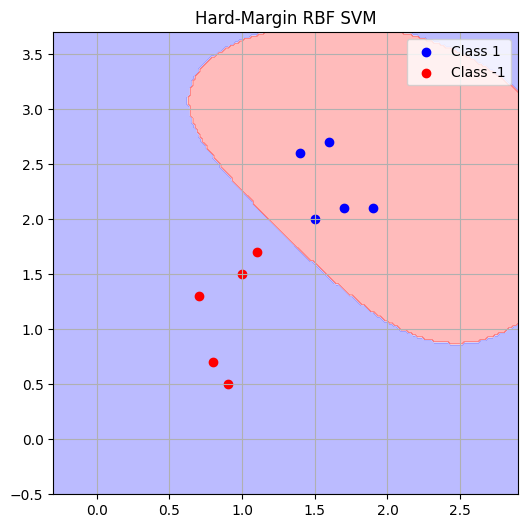

In [8]:
# ----------------------------------------------------
# 예시 실행
# ----------------------------------------------------
gamma = 1.0

# Hard-Margin SVM 결과 
alpha, b = fit_svm_rbf(X, t, gamma=gamma)
print("\n alpha:", alpha)
print(" b:", b)

plt.figure(figsize=(6,6))
plot_decision_boundary(alpha, b, X, t, gamma,
                       title="Hard-Margin RBF SVM")
plt.show()

    

**하이퍼파라미터 설정**  
   - `gamma = 1.0` : RBF 커널에서 가우시안 분포의 폭을 조절하는 하이퍼파라미터이다.

**Hard-Margin SVM 학습**  
   - `fit_svm_rbf(X, t, gamma=gamma)`를 호출해 듀얼 QP 문제를 푼다.  
   - 반환된 `alpha`와 `b`는 학습된 모델 파라미터(라그랑주 승수 벡터와 바이어스 항)이다.

**결과 확인 및 시각화**  
   - 학습된 파라미터를 출력한 뒤,
   - `plot_decision_boundary` 함수를 이용하여 2차원 평면 상의 결정 경계를 시각화한다.  
   - `plt.show()`를 통해 최종 그래프를 표시한다.
   - 학습된 SVM 모델이 두 클래스를 잘 분류하는 것을 볼 수 있다.


## 7. 정리하기

- SVM은 주어진 데이터를 가지고 결정 함수의 마진을 최대화하는 머신러닝 모델이다.
- 프라이멀 문제는 원래 주어진 최적화 문제이고, 듀얼 문제는 최적화 과정에서 라그랑지안을 통해 유도되는 새로운 문제이다.
- 커널 트릭을 적용하면 계산하기 어려운 특징 함수 간의 내적 연산을 대체할 수 있다.
- KKT 조건을 이용하여 제약이 있는 최적화 문제의 해가 만족하는 여러 가지 조건을 이해할 수 있다.
- RBF 커널의 $\gamma$값을 조절하면서, SVM의 성능을 튜닝할 수 있다.